In [ ]:
!pip install yfinance pandas matplotlib seaborn scipy -q

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# download the dataset, NVDA, 3 months
ticker = "NVDA"
period = "3mo"
df = yf.download(ticker, period=period, progress=False)

In [ ]:
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

print(f"Date Range: {df.index[0].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}")
print(f"Total Trading Days: {len(df)}")
df.head()

Date Range: 2025-12-08 to 2026-03-06
Total Trading Days: 61


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-12-08,185.550003,188.000000,182.399994,182.639999,204378100
2025-12-09,184.970001,185.720001,183.320007,185.559998,144719700
2025-12-10,183.779999,185.479996,182.039993,184.970001,162785400
2025-12-11,180.929993,181.320007,176.619995,180.279999,182136600
2025-12-12,175.020004,182.820007,174.619995,181.110001,204274900


In [ ]:
# daily return rate
df['Daily_Return'] = df['Close'].pct_change()
# cumulative return rate
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1
# rolling volatility
df['Rolling_Volatility'] = df['Daily_Return'].rolling(window=20).std() * np.sqrt(252)

df['Rolling_Max'] = df['Close'].cummax()
df['Drawdown'] = (df['Close'] - df['Rolling_Max']) / df['Rolling_Max']

df.tail()

Price,Close,High,Low,Open,Volume,Daily_Return,Cumulative_Return,Rolling_Volatility,Rolling_Max,Drawdown
Date,,,,,,,,,,
2026-03-02,182.479996,183.460007,174.639999,175.009995,209095300,0.029855,-0.016545,0.475514,195.559998,-0.066885
2026-03-03,180.050003,180.899994,176.919998,178.490005,178099400,-0.013316,-0.029642,0.466929,195.559998,-0.079311
2026-03-04,183.039993,184.699997,180.059998,180.440002,177731200,0.016606,-0.013527,0.459318,195.559998,-0.064021
2026-03-05,183.339996,184.059998,177.880005,181.169998,198779700,0.001639,-0.011911,0.440066,195.559998,-0.062487
2026-03-06,177.820007,182.759995,176.820007,179.839996,188472400,-0.030108,-0.041660,0.452180,195.559998,-0.090714


In [ ]:
# price
current_price = df['Close'].iloc[-1]
period_high = df['High'].max()
period_low = df['Low'].min()
avg_volume = df['Volume'].mean()

total_return = df['Cumulative_Return'].iloc[-1]
avg_daily_return = df['Daily_Return'].mean()
daily_volatility = df['Daily_Return'].std()
annualized_volatility = daily_volatility * np.sqrt(252)

max_drawdown = df['Drawdown'].min()
sharpe_ratio = (avg_daily_return / daily_volatility) * np.sqrt(252) if daily_volatility > 0 else 0

returns_clean = df['Daily_Return'].dropna()
skewness = returns_clean.skew()
kurtosis = returns_clean.kurtosis()

print(f"{ticker} STATISTICS SUMMARY")

print(f"Price Statistics:")
print(f"Current Price: ${current_price:.2f}")
print(f"Period High: ${period_high:.2f}")
print(f"Period Low: ${period_low:.2f}")
print(f"Price Range: ${period_high - period_low:.2f} ({(period_high/period_low - 1)*100:.1f}%)")

print(f"Return Statistics:")
print(f"Total Return: {total_return*100:.2f}%")
print(f"Avg Daily Return: {avg_daily_return*100:.4f}%")
print(f"Daily Volatility: {daily_volatility*100:.2f}%")
print(f"Annual Volatility:{annualized_volatility*100:.2f}%")

print(f"\nRisk Metrics:")
print(f"Max Drawdown: {max_drawdown*100:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

print(f"\nDistribution:")
print(f"Skewness: {skewness:.4f} ({'Right-skewed' if skewness > 0 else 'Left-skewed'})")
print(f"Excess Kurtosis: {kurtosis:.4f} ({'Fat tails' if kurtosis > 0 else 'Thin tails'})")

print(f"\nVolume Statistics:")
print(f"Avg Daily Volume: {avg_volume/1e6:.2f}M")

NVDA STATISTICS SUMMARY
Price Statistics:
Current Price: $177.82
Period High: $197.63
Period Low: $170.31
Price Range: $27.32 (16.0%)
Return Statistics:
Total Return: -4.17%
Avg Daily Return: -0.0461%
Daily Volatility: 2.25%
Annual Volatility:35.66%

Risk Metrics:
Max Drawdown: -10.72%
Sharpe Ratio: -0.33

Distribution:
Skewness: 0.2657 (Right-skewed)
Excess Kurtosis: 1.8265 (Fat tails)

Volume Statistics:
Avg Daily Volume: 176.60M


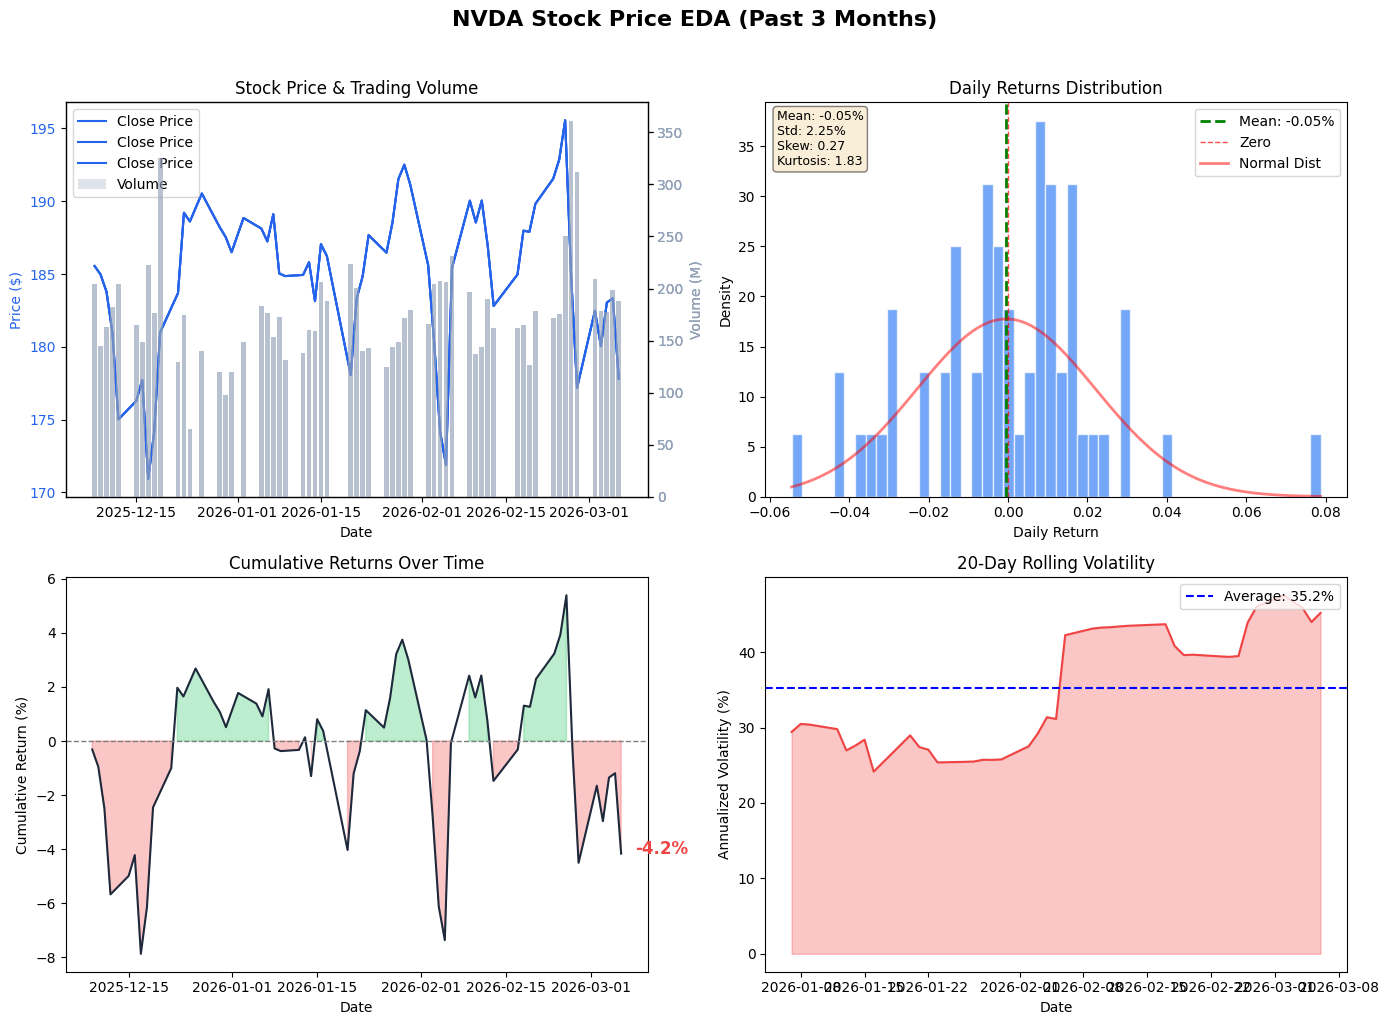

In [ ]:
# plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{ticker} Stock Price EDA (Past 3 Months)', fontsize=16, fontweight='bold', y=1.02)

# price + volume
ax1 = axes[0, 0]
ax1_vol = ax1.twinx()

ax1.plot(df.index, df['Close'], color='#2563eb', linewidth=1.5, label='Close Price')
ax1_vol.bar(df.index, df['Volume']/1e6, alpha=0.3, color='#94a3b8', label='Volume', width=0.8)

ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)', color='#2563eb')
ax1_vol.set_ylabel('Volume (M)', color='#94a3b8')
ax1.set_title('Stock Price & Trading Volume')
ax1.tick_params(axis='y', labelcolor='#2563eb')
ax1_vol.tick_params(axis='y', labelcolor='#94a3b8')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_vol.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1 = axes[0, 0]
ax1_vol = ax1.twinx()

ax1.plot(df.index, df['Close'], color='#2563eb', linewidth=1.5, label='Close Price')
ax1_vol.bar(df.index, df['Volume']/1e6, alpha=0.3, color='#94a3b8', label='Volume', width=0.8)

ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)', color='#2563eb')
ax1_vol.set_ylabel('Volume (M)', color='#94a3b8')
ax1.set_title('Stock Price & Trading Volume')
ax1.tick_params(axis='y', labelcolor='#2563eb')
ax1_vol.tick_params(axis='y', labelcolor='#94a3b8')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_vol.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

#
ax1 = axes[0, 0]
ax1_vol = ax1.twinx()

ax1.plot(df.index, df['Close'], color='#2563eb', linewidth=1.5, label='Close Price')
ax1_vol.bar(df.index, df['Volume']/1e6, alpha=0.3, color='#94a3b8', label='Volume', width=0.8)

ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)', color='#2563eb')
ax1_vol.set_ylabel('Volume (M)', color='#94a3b8')
ax1.set_title('Stock Price & Trading Volume')
ax1.tick_params(axis='y', labelcolor='#2563eb')
ax1_vol.tick_params(axis='y', labelcolor='#94a3b8')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_vol.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax2 = axes[0, 1]

ax2.hist(returns_clean, bins=50, edgecolor='white', alpha=0.7, color='#3b82f6', density=True)
ax2.axvline(x=returns_clean.mean(), color='green', linestyle='--', linewidth=2,
            label=f'Mean: {returns_clean.mean()*100:.2f}%')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Zero')

x_range = np.linspace(returns_clean.min(), returns_clean.max(), 100)
pdf = stats.norm.pdf(x_range, returns_clean.mean(), returns_clean.std())
ax2.plot(x_range, pdf, 'r-', linewidth=2, alpha=0.5, label='Normal Dist')

ax2.set_xlabel('Daily Return')
ax2.set_ylabel('Density')
ax2.set_title('Daily Returns Distribution')
ax2.legend(loc='upper right')

textstr = f'Mean: {returns_clean.mean()*100:.2f}%\nStd: {returns_clean.std()*100:.2f}%\nSkew: {skewness:.2f}\nKurtosis: {kurtosis:.2f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax2.text(0.02, 0.98, textstr, transform=ax2.transAxes, fontsize=9, verticalalignment='top', bbox=props)


ax3 = axes[1, 0]

ax3.fill_between(df.index, df['Cumulative_Return']*100, where=(df['Cumulative_Return'] >= 0), alpha=0.3, color='#22c55e')
ax3.fill_between(df.index, df['Cumulative_Return']*100, where=(df['Cumulative_Return'] < 0), alpha=0.3, color='#ef4444')
ax3.plot(df.index, df['Cumulative_Return']*100, color='#1e293b', linewidth=1.5)
ax3.axhline(y=0, color='gray', linestyle='--', linewidth=1)

final_return = df['Cumulative_Return'].iloc[-1] * 100
ax3.annotate(f'{final_return:.1f}%',
             xy=(df.index[-1], final_return),
             xytext=(10, 0), textcoords='offset points',
             fontsize=12, fontweight='bold',
             color='#22c55e' if final_return >= 0 else '#ef4444')

ax3.set_xlabel('Date')
ax3.set_ylabel('Cumulative Return (%)')
ax3.set_title('Cumulative Returns Over Time')


ax4 = axes[1, 1]

ax4.plot(df.index, df['Rolling_Volatility']*100, color='#ef4444', linewidth=1.5)
ax4.fill_between(df.index, df['Rolling_Volatility']*100, alpha=0.3, color='#ef4444')

avg_vol = df['Rolling_Volatility'].mean() * 100
ax4.axhline(y=avg_vol, color='blue', linestyle='--', linewidth=1.5, label=f'Average: {avg_vol:.1f}%')

ax4.set_xlabel('Date')
ax4.set_ylabel('Annualized Volatility (%)')
ax4.set_title('20-Day Rolling Volatility')
ax4.legend(loc='upper right')

plt.tight_layout()
plt.savefig('eda_stock_price.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# summary data
summary_data = {
    'Metric': [
        'Ticker', 'Analysis Period', 'Trading Days', 'Current Price',
        'Period High', 'Period Low', 'Total Return', 'Avg Daily Return',
        'Daily Volatility', 'Annualized Volatility', 'Max Drawdown',
        'Sharpe Ratio', 'Skewness', 'Kurtosis', 'Avg Daily Volume'
    ],
    'Value': [
        ticker,
        f"{df.index[0].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}",
        len(df),
        f"${current_price:.2f}",
        f"${period_high:.2f}",
        f"${period_low:.2f}",
        f"{total_return*100:.2f}%",
        f"{avg_daily_return*100:.4f}%",
        f"{daily_volatility*100:.2f}%",
        f"{annualized_volatility*100:.2f}%",
        f"{max_drawdown*100:.2f}%",
        f"{sharpe_ratio:.2f}",
        f"{skewness:.4f}",
        f"{kurtosis:.4f}",
        f"{avg_volume/1e6:.2f}M"
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('eda_stock_summary.csv', index=False)

print("Summary Table:")
summary_df

Summary Table:


,Metric,Value
0,Ticker,NVDA
1,Analysis Period,2025-12-08 to 2026-03-06
2,Trading Days,61
3,Current Price,$177.82
4,Period High,$197.63
5,Period Low,$170.31
6,Total Return,-4.17%
7,Avg Daily Return,-0.0461%
8,Daily Volatility,2.25%
9,Annualized Volatility,35.66%


In [ ]:
print("Normality Tests for Daily Returns")

# Shapiro-Wilk
stat_shapiro, p_shapiro = stats.shapiro(returns_clean)
print(f"\n1. Shapiro-Wilk Test:")
print(f"Statistic: {stat_shapiro:.4f}")
print(f"p-value:   {p_shapiro:.4f}")
print(f"Result:    {'Normal' if p_shapiro > 0.05 else 'NOT Normal'}")

# Jarque-Bera
stat_jb, p_jb = stats.jarque_bera(returns_clean)
print(f"\n2. Jarque-Bera Test:")
print(f"Statistic: {stat_jb:.4f}")
print(f"p-value: {p_jb:.4f}")
print(f"Result: {'Normal' if p_jb > 0.05 else 'NOT Normal'}")

print(f"\nInterpretation:")
if p_shapiro < 0.05 or p_jb < 0.05:
    print("The daily returns do NOT follow a normal distribution.")
    print("This is common for stock returns (fat tails, skewness).")
else:
    print("The daily returns approximately follow a normal distribution.")

Normality Tests for Daily Returns

1. Shapiro-Wilk Test:
Statistic: 0.9642
p-value:   0.0759
Result:    Normal

2. Jarque-Bera Test:
Statistic: 6.9071
p-value: 0.0316
Result: NOT Normal

Interpretation:
The daily returns do NOT follow a normal distribution.
This is common for stock returns (fat tails, skewness).


In [ ]:
!pip install yfinance pandas-ta matplotlib seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 18.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is 

In [ ]:
import pandas_ta as ta
# moving averages
df['SMA_10'] = ta.sma(df['Close'], length=10)
df['SMA_20'] = ta.sma(df['Close'], length=20)
df['SMA_50'] = ta.sma(df['Close'], length=50)
df['EMA_12'] = ta.ema(df['Close'], length=12)
df['EMA_26'] = ta.ema(df['Close'], length=26)

# RSI
df['RSI'] = ta.rsi(df['Close'], length=14)

# MACD (Moving Average Convergence Divergence
macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
df['MACD'] = macd['MACD_12_26_9']
df['MACD_Signal'] = macd['MACDs_12_26_9']
df['MACD_Hist'] = macd['MACDh_12_26_9']

# Bollinger Bands
bbands = ta.bbands(df['Close'], length=20, std=2)
for col in bbands.columns:
    if 'BBL' in col:
        df['BB_Lower'] = bbands[col]
    elif 'BBM' in col:
        df['BB_Middle'] = bbands[col]
    elif 'BBU' in col:
        df['BB_Upper'] = bbands[col]
df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['BB_Middle']


# Stochastic Oscillator
stoch = ta.stoch(df['High'], df['Low'], df['Close'], k=14, d=3)
df['Stoch_K'] = stoch['STOCHk_14_3_3']
df['Stoch_D'] = stoch['STOCHd_14_3_3']

# ATR
df['ATR'] = ta.atr(df['High'], df['Low'], df['Close'], length=14)

# OBV
df['OBV'] = ta.obv(df['Close'], df['Volume'])

# ADX
adx = ta.adx(df['High'], df['Low'], df['Close'], length=14)
df['ADX'] = adx['ADX_14']
df['DI_Plus'] = adx['DMP_14']
df['DI_Minus'] = adx['DMN_14']

# Momentum
df['Momentum'] = ta.mom(df['Close'], length=10)
df['ROC'] = ta.roc(df['Close'], length=10)

df.tail()


Price,Close,High,Low,Open,Volume,Daily_Return,Cumulative_Return,Rolling_Volatility,Rolling_Max,Drawdown,...,BB_Width,Stoch_K,Stoch_D,ATR,OBV,ADX,DI_Plus,DI_Minus,Momentum,ROC
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-02,182.479996,183.460007,174.639999,175.009995,209095300,0.029855,-0.016545,0.475514,195.559998,-0.066885,...,0.130953,27.531446,50.600502,6.566170,-35360500.0,13.566339,19.756099,34.868638,-0.330002,-0.180516
2026-03-03,180.050003,180.899994,176.919998,178.490005,178099400,-0.013316,-0.029642,0.466929,195.559998,-0.079311,...,0.133807,20.481831,31.638936,6.494300,-213459900.0,14.573466,18.547660,32.735795,-4.919998,-2.659890
2026-03-04,183.039993,184.699997,180.059998,180.440002,177731200,0.016606,-0.013527,0.459318,195.559998,-0.064021,...,0.131892,31.390443,26.467907,6.362564,-35728700.0,14.772713,21.846240,31.026493,-4.940002,-2.627941
2026-03-05,183.339996,184.059998,177.880005,181.169998,198779700,0.001639,-0.011911,0.440066,195.559998,-0.062487,...,0.119352,32.637363,28.169879,6.349523,163051000.0,15.238056,20.327120,31.321922,-4.559998,-2.426822
2026-03-06,177.820007,182.759995,176.820007,179.839996,188472400,-0.030108,-0.041660,0.452180,195.559998,-0.090714,...,0.104772,29.404080,31.143962,6.361700,-25421400.0,15.806588,18.838750,30.218902,-12.000000,-6.321778


In [ ]:
print("Bollinger Bands columns:", bbands.columns.tolist())

Bollinger Bands columns: ['BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0']


In [ ]:
print(f"{ticker} TECHNICAL INDICATORS SUMMARY")

current_price = df['Close'].iloc[-1]
current_rsi = df['RSI'].iloc[-1]
current_macd = df['MACD'].iloc[-1]
current_macd_signal = df['MACD_Signal'].iloc[-1]
current_adx = df['ADX'].iloc[-1]
current_stoch_k = df['Stoch_K'].iloc[-1]

print(f"\nCurrent Price: ${current_price:.2f}")

# RSI
print(f"\nRSI (14): {current_rsi:.2f}")
if current_rsi > 70:
    print(f" → OVERBOUGHT (RSI > 70)")
elif current_rsi < 30:
    print(f" → OVERSOLD (RSI < 30)")
else:
    print(f" → NEUTRAL (30 < RSI < 70)")

# MACD
print(f"\nMACD: {current_macd:.2f}")
print(f"Signal: {current_macd_signal:.2f}")
if current_macd > current_macd_signal:
    print(f" → BULLISH (MACD > Signal)")
else:
    print(f" → BEARISH (MACD < Signal)")

sma20 = df['SMA_20'].iloc[-1]
sma50 = df['SMA_50'].iloc[-1]
print(f"\nMoving Averages:")
print(f" SMA 20: ${sma20:.2f}")
print(f" SMA 50: ${sma50:.2f}")
if current_price > sma20 > sma50:
    print(f" → BULLISH (Price > SMA20 > SMA50)")
elif current_price < sma20 < sma50:
    print(f" → BEARISH (Price < SMA20 < SMA50)")
else:
    print(f" → MIXED signals")

# ADX
print(f"\nADX (Trend Strength): {current_adx:.2f}")
if current_adx > 25:
    print(f" → STRONG TREND")
else:
    print(f" → WEAK/NO TREND")

# Bollinger Bands
bb_upper = df['BB_Upper'].iloc[-1]
bb_lower = df['BB_Lower'].iloc[-1]
print(f"\nBollinger Bands:")
print(f" Upper: ${bb_upper:.2f}")
print(f" Lower: ${bb_lower:.2f}")
if current_price > bb_upper:
    print(f" → Price ABOVE upper band (potential reversal)")
elif current_price < bb_lower:
    print(f" → Price BELOW lower band (potential reversal)")
else:
    print(f" → Price within bands")

# Stochastic
print(f"\ntochastic %K: {current_stoch_k:.2f}")
if current_stoch_k > 80:
    print(f" → OVERBOUGHT")
elif current_stoch_k < 20:
    print(f" → OVERSOLD")
else:
    print(f" → NEUTRAL")

NVDA TECHNICAL INDICATORS SUMMARY

Current Price: $177.82

RSI (14): 42.24
 → NEUTRAL (30 < RSI < 70)

MACD: -1.15
Signal: -0.12
 → BEARISH (MACD < Signal)

Moving Averages:
 SMA 20: $186.16
 SMA 50: $186.01
 → MIXED signals

ADX (Trend Strength): 15.81
 → WEAK/NO TREND

Bollinger Bands:
 Upper: $195.91
 Lower: $176.41
 → Price within bands

tochastic %K: 29.40
 → NEUTRAL


In [ ]:
print("Signal Statistics (Past 3 Months)")

# RSI
rsi_overbought = (df['RSI'] > 70).sum()
rsi_oversold = (df['RSI'] < 30).sum()
print(f"\nRSI Signals:")
print(f" Overbought days (>70): {rsi_overbought}")
print(f" Oversold days (<30): {rsi_oversold}")

# MACD
macd_cross = df['MACD'] - df['MACD_Signal']
golden_cross = ((macd_cross > 0) & (macd_cross.shift(1) < 0)).sum()
death_cross = ((macd_cross < 0) & (macd_cross.shift(1) > 0)).sum()
print(f"\nMACD Crossovers:")
print(f" Golden Cross (bullish): {golden_cross}")
print(f" Death Cross (bearish): {death_cross}")

ma_cross = df['SMA_20'] - df['SMA_50']
ma_golden = ((ma_cross > 0) & (ma_cross.shift(1) < 0)).sum()
ma_death = ((ma_cross < 0) & (ma_cross.shift(1) > 0)).sum()
print(f"\nMA Crossovers (SMA20 vs SMA50):")
print(f" Golden Cross: {ma_golden}")
print(f" Death Cross: {ma_death}")

# Bollinger Band
bb_above = (df['Close'] > df['BB_Upper']).sum()
bb_below = (df['Close'] < df['BB_Lower']).sum()
print(f"\nBollinger Band Breakouts:")
print(f" Above upper band: {bb_above} days")
print(f" Below lower band: {bb_below} days")

Signal Statistics (Past 3 Months)

RSI Signals:
 Overbought days (>70): 0
 Oversold days (<30): 8

MACD Crossovers:
 Golden Cross (bullish): 2
 Death Cross (bearish): 3

MA Crossovers (SMA20 vs SMA50):
 Golden Cross: 1
 Death Cross: 1

Bollinger Band Breakouts:
 Above upper band: 0 days
 Below lower band: 3 days


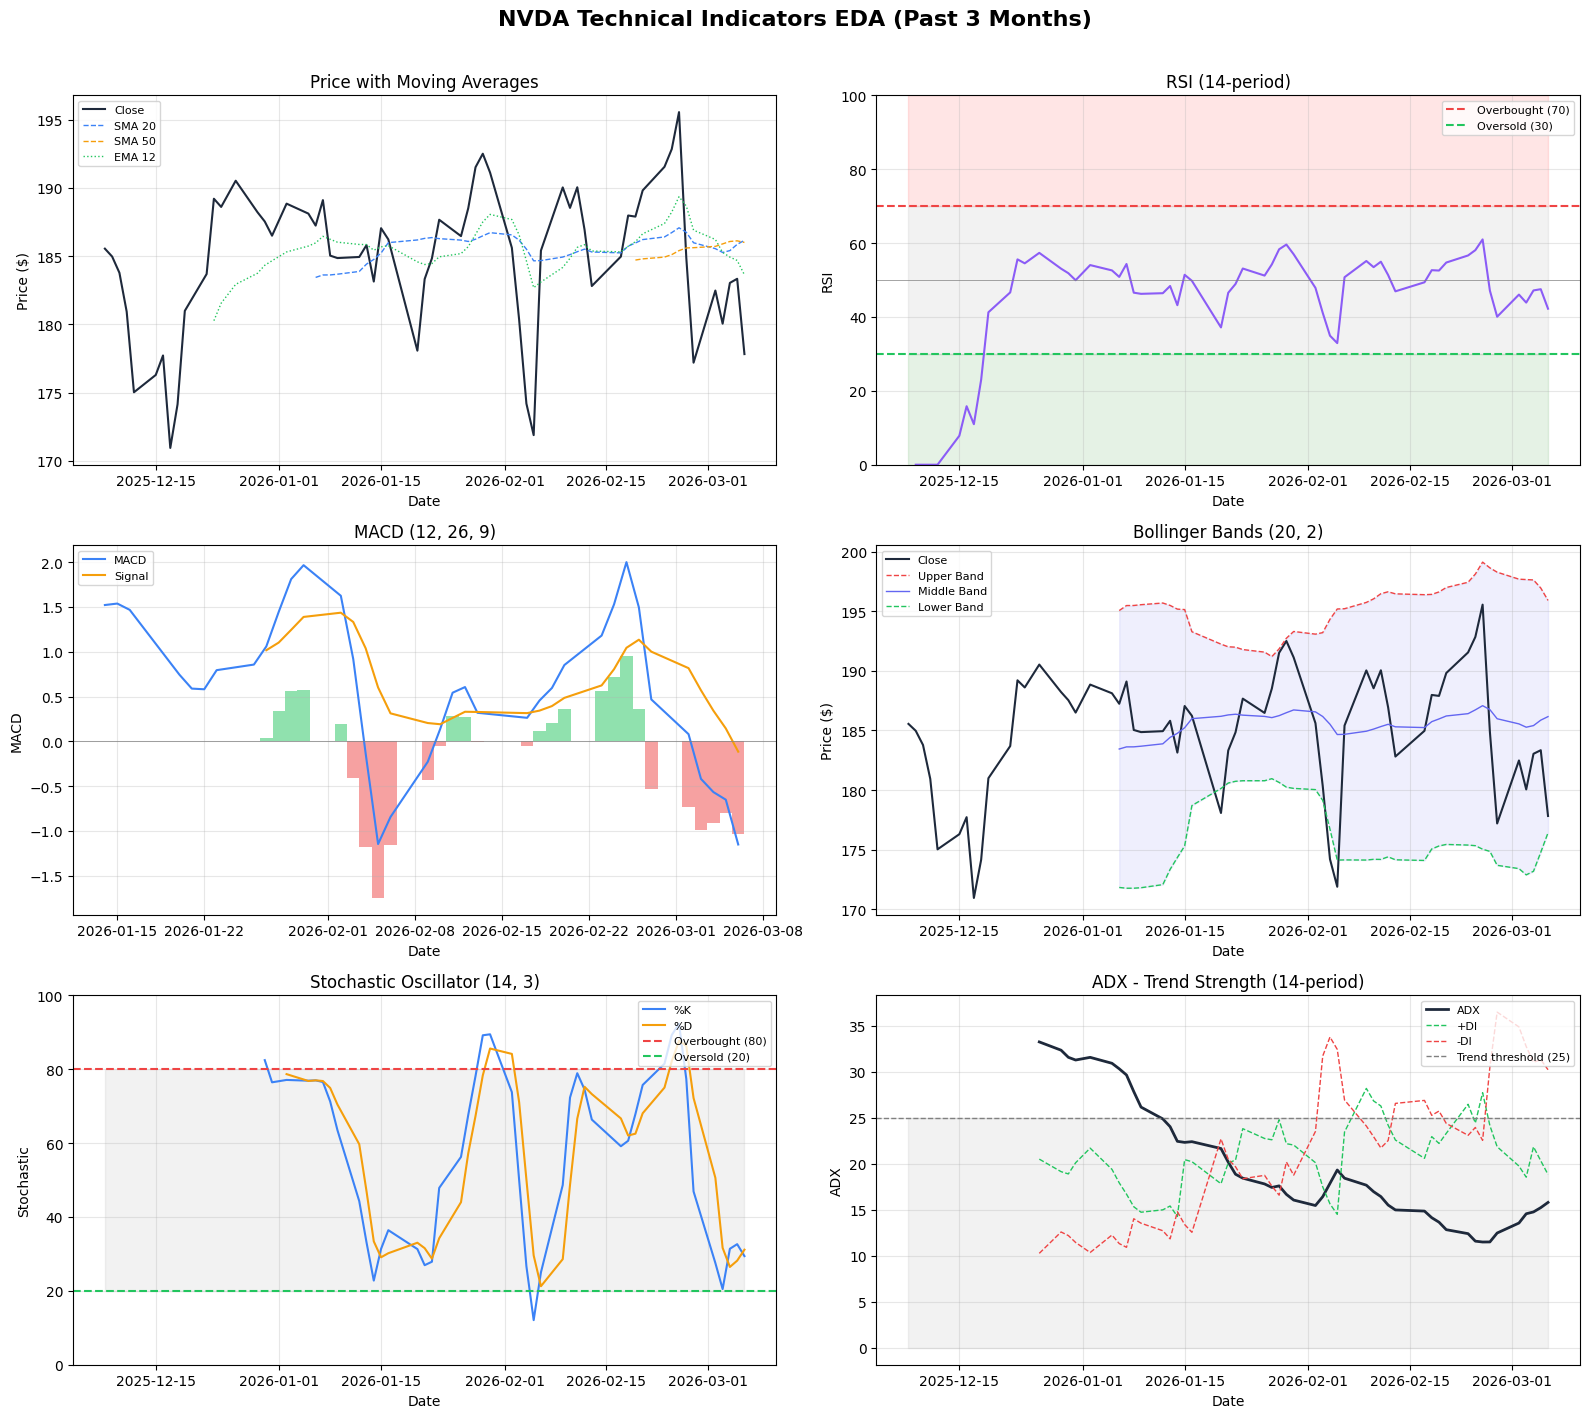

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle(f'{ticker} Technical Indicators EDA (Past 3 Months)', fontsize=16, fontweight='bold', y=1.01)
ax1 = axes[0, 0]
ax1.plot(df.index, df['Close'], label='Close', color='#1e293b', linewidth=1.5)
ax1.plot(df.index, df['SMA_20'], label='SMA 20', color='#3b82f6', linewidth=1, linestyle='--')
ax1.plot(df.index, df['SMA_50'], label='SMA 50', color='#f59e0b', linewidth=1, linestyle='--')
ax1.plot(df.index, df['EMA_12'], label='EMA 12', color='#22c55e', linewidth=1, linestyle=':')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)')
ax1.set_title('Price with Moving Averages')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(df.index, df['RSI'], color='#8b5cf6', linewidth=1.5)
ax2.axhline(y=70, color='#ef4444', linestyle='--', linewidth=1.5, label='Overbought (70)')
ax2.axhline(y=30, color='#22c55e', linestyle='--', linewidth=1.5, label='Oversold (30)')
ax2.axhline(y=50, color='gray', linestyle='-', linewidth=0.5)
ax2.fill_between(df.index, 30, 70, alpha=0.1, color='gray')
ax2.fill_between(df.index, 70, 100, alpha=0.1, color='red')
ax2.fill_between(df.index, 0, 30, alpha=0.1, color='green')
ax2.set_xlabel('Date')
ax2.set_ylabel('RSI')
ax2.set_title('RSI (14-period)')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
ax3.plot(df.index, df['MACD'], label='MACD', color='#3b82f6', linewidth=1.5)
ax3.plot(df.index, df['MACD_Signal'], label='Signal', color='#f59e0b', linewidth=1.5)
colors_hist = ['#22c55e' if v >= 0 else '#ef4444' for v in df['MACD_Hist']]
ax3.bar(df.index, df['MACD_Hist'], color=colors_hist, alpha=0.5, width=1)
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Date')
ax3.set_ylabel('MACD')
ax3.set_title('MACD (12, 26, 9)')
ax3.legend(loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
ax4.plot(df.index, df['Close'], label='Close', color='#1e293b', linewidth=1.5)
ax4.plot(df.index, df['BB_Upper'], label='Upper Band', color='#ef4444', linewidth=1, linestyle='--')
ax4.plot(df.index, df['BB_Middle'], label='Middle Band', color='#6366f1', linewidth=1, linestyle='-')
ax4.plot(df.index, df['BB_Lower'], label='Lower Band', color='#22c55e', linewidth=1, linestyle='--')
ax4.fill_between(df.index, df['BB_Lower'], df['BB_Upper'], alpha=0.1, color='#6366f1')
ax4.set_xlabel('Date')
ax4.set_ylabel('Price ($)')
ax4.set_title('Bollinger Bands (20, 2)')
ax4.legend(loc='upper left', fontsize=8)
ax4.grid(True, alpha=0.3)

ax5 = axes[2, 0]
ax5.plot(df.index, df['Stoch_K'], label='%K', color='#3b82f6', linewidth=1.5)
ax5.plot(df.index, df['Stoch_D'], label='%D', color='#f59e0b', linewidth=1.5)
ax5.axhline(y=80, color='#ef4444', linestyle='--', linewidth=1.5, label='Overbought (80)')
ax5.axhline(y=20, color='#22c55e', linestyle='--', linewidth=1.5, label='Oversold (20)')
ax5.fill_between(df.index, 20, 80, alpha=0.1, color='gray')
ax5.set_xlabel('Date')
ax5.set_ylabel('Stochastic')
ax5.set_title('Stochastic Oscillator (14, 3)')
ax5.set_ylim(0, 100)
ax5.legend(loc='upper right', fontsize=8)
ax5.grid(True, alpha=0.3)

ax6 = axes[2, 1]
ax6.plot(df.index, df['ADX'], label='ADX', color='#1e293b', linewidth=2)
ax6.plot(df.index, df['DI_Plus'], label='+DI', color='#22c55e', linewidth=1, linestyle='--')
ax6.plot(df.index, df['DI_Minus'], label='-DI', color='#ef4444', linewidth=1, linestyle='--')
ax6.axhline(y=25, color='gray', linestyle='--', linewidth=1, label='Trend threshold (25)')
ax6.fill_between(df.index, 0, 25, alpha=0.1, color='gray')
ax6.set_xlabel('Date')
ax6.set_ylabel('ADX')
ax6.set_title('ADX - Trend Strength (14-period)')
ax6.legend(loc='upper right', fontsize=8)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_technical_indicators.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


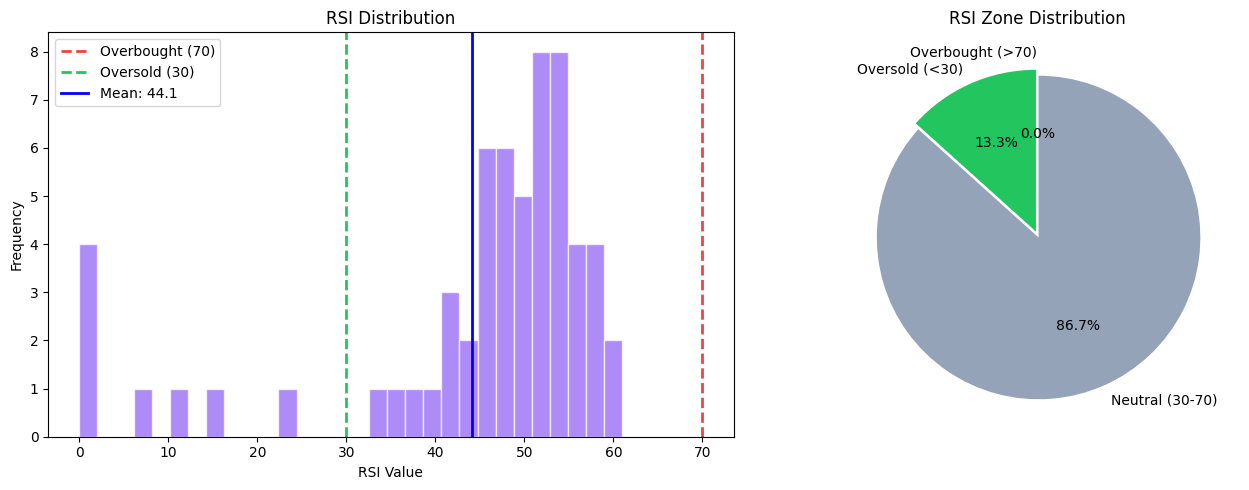

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RSI
ax1 = axes[0]
ax1.hist(df['RSI'].dropna(), bins=30, edgecolor='white', alpha=0.7, color='#8b5cf6')
ax1.axvline(x=70, color='#ef4444', linestyle='--', linewidth=2, label='Overbought (70)')
ax1.axvline(x=30, color='#22c55e', linestyle='--', linewidth=2, label='Oversold (30)')
ax1.axvline(x=df['RSI'].mean(), color='blue', linestyle='-', linewidth=2,
            label=f"Mean: {df['RSI'].mean():.1f}")
ax1.set_xlabel('RSI Value')
ax1.set_ylabel('Frequency')
ax1.set_title('RSI Distribution')
ax1.legend()

ax2 = axes[1]
rsi_zones = {
    'Oversold (<30)': (df['RSI'] < 30).sum(),
    'Neutral (30-70)': ((df['RSI'] >= 30) & (df['RSI'] <= 70)).sum(),
    'Overbought (>70)': (df['RSI'] > 70).sum()
}
colors_zones = ['#22c55e', '#94a3b8', '#ef4444']
ax2.pie(rsi_zones.values(), labels=rsi_zones.keys(), colors=colors_zones,
        autopct='%1.1f%%', startangle=90, explode=[0.02, 0.02, 0.02])
ax2.set_title('RSI Zone Distribution')

plt.tight_layout()
plt.savefig('eda_rsi_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


In [ ]:
export_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
               'SMA_20', 'SMA_50', 'EMA_12', 'RSI',
               'MACD', 'MACD_Signal', 'MACD_Hist',
               'BB_Upper', 'BB_Middle', 'BB_Lower',
               'Stoch_K', 'Stoch_D', 'ADX', 'ATR']

df_export = df[export_cols].copy()
df_export.to_csv('eda_indicators_data.csv')
df_export.tail()

Price,Open,High,Low,Close,Volume,SMA_20,SMA_50,EMA_12,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,Stoch_K,Stoch_D,ADX,ATR
Date,,,,,,,,,,,,,,,,,,,
2026-03-02,175.009995,183.460007,174.639999,182.479996,209095300,185.5500,185.716201,186.225199,46.055604,0.079927,0.816365,-0.736437,197.699182,185.5500,173.400818,27.531446,50.600502,13.566339,6.566170
2026-03-03,178.490005,180.899994,176.919998,180.050003,178099400,185.2720,185.898401,185.275169,43.886385,-0.418602,0.569371,-0.987973,197.667357,185.2720,172.876643,20.481831,31.638936,14.573466,6.494300
2026-03-04,180.440002,184.699997,180.059998,183.039993,177731200,185.4070,186.076400,184.931296,47.182828,-0.565899,0.342317,-0.908216,197.633854,185.4070,173.180146,31.390443,26.467907,14.772713,6.362564
2026-03-05,181.169998,184.059998,177.880005,183.339996,198779700,185.8645,186.123400,184.686480,47.515982,-0.650922,0.143670,-0.794591,196.956186,185.8645,174.772813,32.637363,28.169879,15.238056,6.349523
2026-03-06,179.839996,182.759995,176.820007,177.820007,188472400,186.1615,186.006000,183.630100,42.236893,-1.150458,-0.115156,-1.035302,195.913744,186.1615,176.409255,29.404080,31.143962,15.806588,6.361700


In [ ]:
from google.colab import files

print("\nDownloading files...")
files.download('eda_technical_indicators.png')
files.download('eda_rsi_analysis.png')
files.download('eda_indicators_data.csv')

print("TECHNICAL INDICATORS EDA COMPLETE!")
print("=" * 60)
print("\nGenerated files:")
print(" eda_technical_indicators.png - Main 6-panel visualization")
print(" eda_indicators_correlation.png - Correlation heatmap")
print(" eda_rsi_analysis.png - RSI distribution analysis")
print(" eda_indicators_summary.csv - Current values summary")
print(" eda_indicators_data.csv - Full data with all indicators")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

TECHNICAL INDICATORS EDA COMPLETE!

Generated files:
 eda_technical_indicators.png - Main 6-panel visualization
 eda_indicators_correlation.png - Correlation heatmap
 eda_rsi_analysis.png - RSI distribution analysis
 eda_indicators_summary.csv - Current values summary
 eda_indicators_data.csv - Full data with all indicators
